In [ ]:
import os, sys

os.system('pip uninstall unsloth unsloth_zoo -y -q')
os.system('pip install --no-cache-dir --upgrade "unsloth_zoo @ git+https://github.com/unslothai/unsloth-zoo.git" -q')
os.system('pip install --no-cache-dir --upgrade "unsloth[kaggle-new] @ git+https://github.com/unslothai/unsloth.git" -q')
os.system('pip install "transformers==5.3.0" "trl>=0.18.2,<=0.24.0,!=0.19.0" -q')
os.system('pip install "datasets>=3.4.1" -q')
os.system('pip install cut_cross_entropy -q')

for mod in list(sys.modules):
    if mod.startswith(("unsloth", "unsloth_zoo")):
        del sys.modules[mod]

import torch
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

print("\n✅ Done!")


In [ ]:
from unsloth import FastLanguageModel
from datasets import load_dataset, Dataset
from trl import SFTTrainer, SFTConfig
import json
import torch

print("Libraries imported successfully")

# ── HuggingFace tokens ─────────────────────────────────────
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

secrets   = UserSecretsClient()
HF_TOKEN       = secrets.get_secret("HF_TOKEN")        # read — for loading models
HF_TOKEN_WRITE = secrets.get_secret("DiplomaWrite")    # write — for pushing checkpoints

login(token=HF_TOKEN_WRITE)   # login with write token
print("HuggingFace login successful ✓")
print(f"  Read token  (HF_TOKEN)    : {HF_TOKEN[:8]}...")
print(f"  Write token (DiplomaWrite): {HF_TOKEN_WRITE[:8]}...")


In [ ]:
# Load model
print("Loading Llama-3.2-1B-Instruct model...")

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = "unsloth/Llama-3.2-1B-Instruct",
    max_seq_length = 512,
    load_in_4bit   = True,
    token          = HF_TOKEN,
)

print("\nModel loaded successfully!")
print(f"Model parameters: {model.num_parameters():,}")

In [ ]:
# Add LoRA adapters
model = FastLanguageModel.get_peft_model(
    model,
    r              = 16,
    lora_alpha     = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_dropout   = 0,
    bias           = "none",
    use_gradient_checkpointing = "unsloth",
    random_state   = 42,
)
model.print_trainable_parameters()

EDA — ECOMMERCE FUNCTION CALLING DATASET

Total conversations : 12000
Generated date      : 2026-03-28T16:06:59.004227
Version             : 2.0

Scenario Distribution:
  simple_order                  :  3000 ████████████████████████████████████████████████████████████
  multi_item_order              :  2400 ████████████████████████████████████████████████
  search_products               :  1800 ████████████████████████████████████
  order_with_size_change        :  1200 ████████████████████████
  order_with_color_change       :   960 ███████████████████
  track_order                   :   960 ███████████████████
  order_cancellation            :   720 ██████████████
  return_request                :   480 █████████
  order_history                 :   240 ████
  out_of_stock                  :   240 ████

Messages per conversation:
  Min    : 5
  Max    : 30
  Mean   : 17.1

Tool calls per conversation:
  Min    : 1
  Max    : 9
  Mean   : 4.7

Most called functions:
  check_product_av

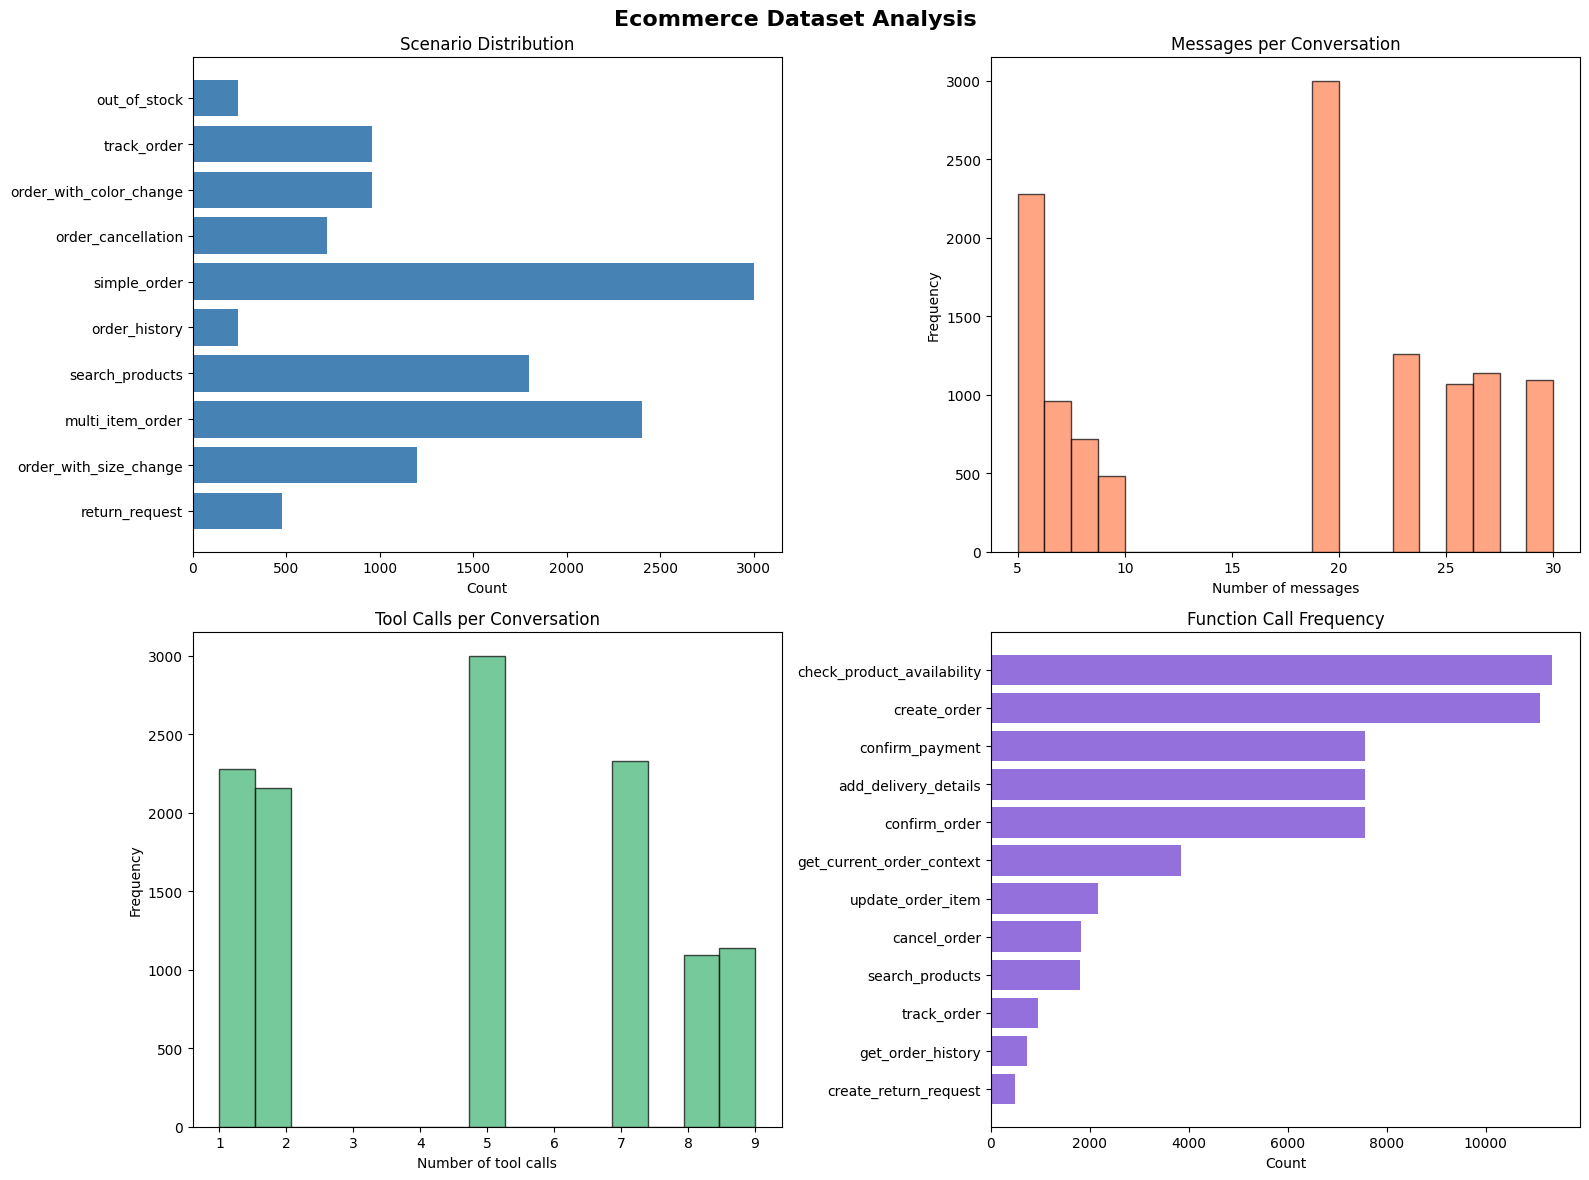


Plot saved: eda_ecommerce.png


In [5]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

print("="*60)
print("EDA — ECOMMERCE FUNCTION CALLING DATASET")
print("="*60)

with open('/kaggle/input/datasets/manoilokatya/ecommerce-function-calling-12000/ecommerce_function_calling_12000.json',
          'r', encoding='utf-8') as f:
    ecommerce_raw = json.load(f)

conversations = ecommerce_raw["conversations"]

print(f"\nTotal conversations : {len(conversations)}")
print(f"Generated date      : {ecommerce_raw['metadata']['generated_date']}")
print(f"Version             : {ecommerce_raw['metadata']['version']}")

scenarios     = [c["scenario"] for c in conversations]
scenario_dist = Counter(scenarios)

print(f"\nScenario Distribution:")
for scenario, count in sorted(scenario_dist.items(), key=lambda x: -x[1]):
    bar = "█" * (count // 50)
    print(f"  {scenario:30s}: {count:5d} {bar}")

msg_counts    = [len(c["messages"]) for c in conversations]
tool_counts   = []
for c in conversations:
    tools = sum(1 for m in c["messages"] if "tool_calls" in m)
    tool_counts.append(tools)

print(f"\nMessages per conversation:")
print(f"  Min    : {min(msg_counts)}")
print(f"  Max    : {max(msg_counts)}")
print(f"  Mean   : {sum(msg_counts)/len(msg_counts):.1f}")

print(f"\nTool calls per conversation:")
print(f"  Min    : {min(tool_counts)}")
print(f"  Max    : {max(tool_counts)}")
print(f"  Mean   : {sum(tool_counts)/len(tool_counts):.1f}")

all_tools = []
for c in conversations:
    for m in c["messages"]:
        if "tool_calls" in m:
            for tc in m["tool_calls"]:
                all_tools.append(tc["name"])

tool_dist = Counter(all_tools)
print(f"\nMost called functions:")
for tool, count in tool_dist.most_common():
    bar = "█" * (count // 100)
    print(f"  {tool:35s}: {count:5d} {bar}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Ecommerce Dataset Analysis", fontsize=16, fontweight="bold")

# 1. Scenario distribution
axes[0,0].barh(list(scenario_dist.keys()), list(scenario_dist.values()), color="steelblue")
axes[0,0].set_title("Scenario Distribution")
axes[0,0].set_xlabel("Count")

# 2. Messages per conversation
axes[0,1].hist(msg_counts, bins=20, color="coral", edgecolor="black", alpha=0.7)
axes[0,1].set_title("Messages per Conversation")
axes[0,1].set_xlabel("Number of messages")
axes[0,1].set_ylabel("Frequency")

# 3. Tool calls per conversation
axes[1,0].hist(tool_counts, bins=15, color="mediumseagreen", edgecolor="black", alpha=0.7)
axes[1,0].set_title("Tool Calls per Conversation")
axes[1,0].set_xlabel("Number of tool calls")
axes[1,0].set_ylabel("Frequency")

# 4. Function call frequency
tools_names  = [t for t, _ in tool_dist.most_common()]
tools_values = [v for _, v in tool_dist.most_common()]
axes[1,1].barh(tools_names, tools_values, color="mediumpurple")
axes[1,1].set_title("Function Call Frequency")
axes[1,1].set_xlabel("Count")
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.savefig('/kaggle/working/eda_ecommerce.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: eda_ecommerce.png")


EDA — BITEXT CUSTOMER SUPPORT DATASET


README.md: 0.00B [00:00, ?B/s]

Bitext_Sample_Customer_Support_Training_(…):   0%|          | 0.00/19.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]


Total examples : 26872
Columns        : ['flags', 'instruction', 'category', 'intent', 'response']

Categories (11):
  ACCOUNT                       :  5986 ███████████████████████████████████████████████████████████
  ORDER                         :  3988 ███████████████████████████████████████
  REFUND                        :  2992 █████████████████████████████
  CONTACT                       :  1999 ███████████████████
  INVOICE                       :  1999 ███████████████████
  PAYMENT                       :  1998 ███████████████████
  FEEDBACK                      :  1997 ███████████████████
  DELIVERY                      :  1994 ███████████████████
  SHIPPING                      :  1970 ███████████████████
  SUBSCRIPTION                  :   999 █████████
  CANCEL                        :   950 █████████

Intents (27):
  contact_customer_service           :  1000
  complaint                          :  1000
  check_invoice                      :  1000
  switch_account      

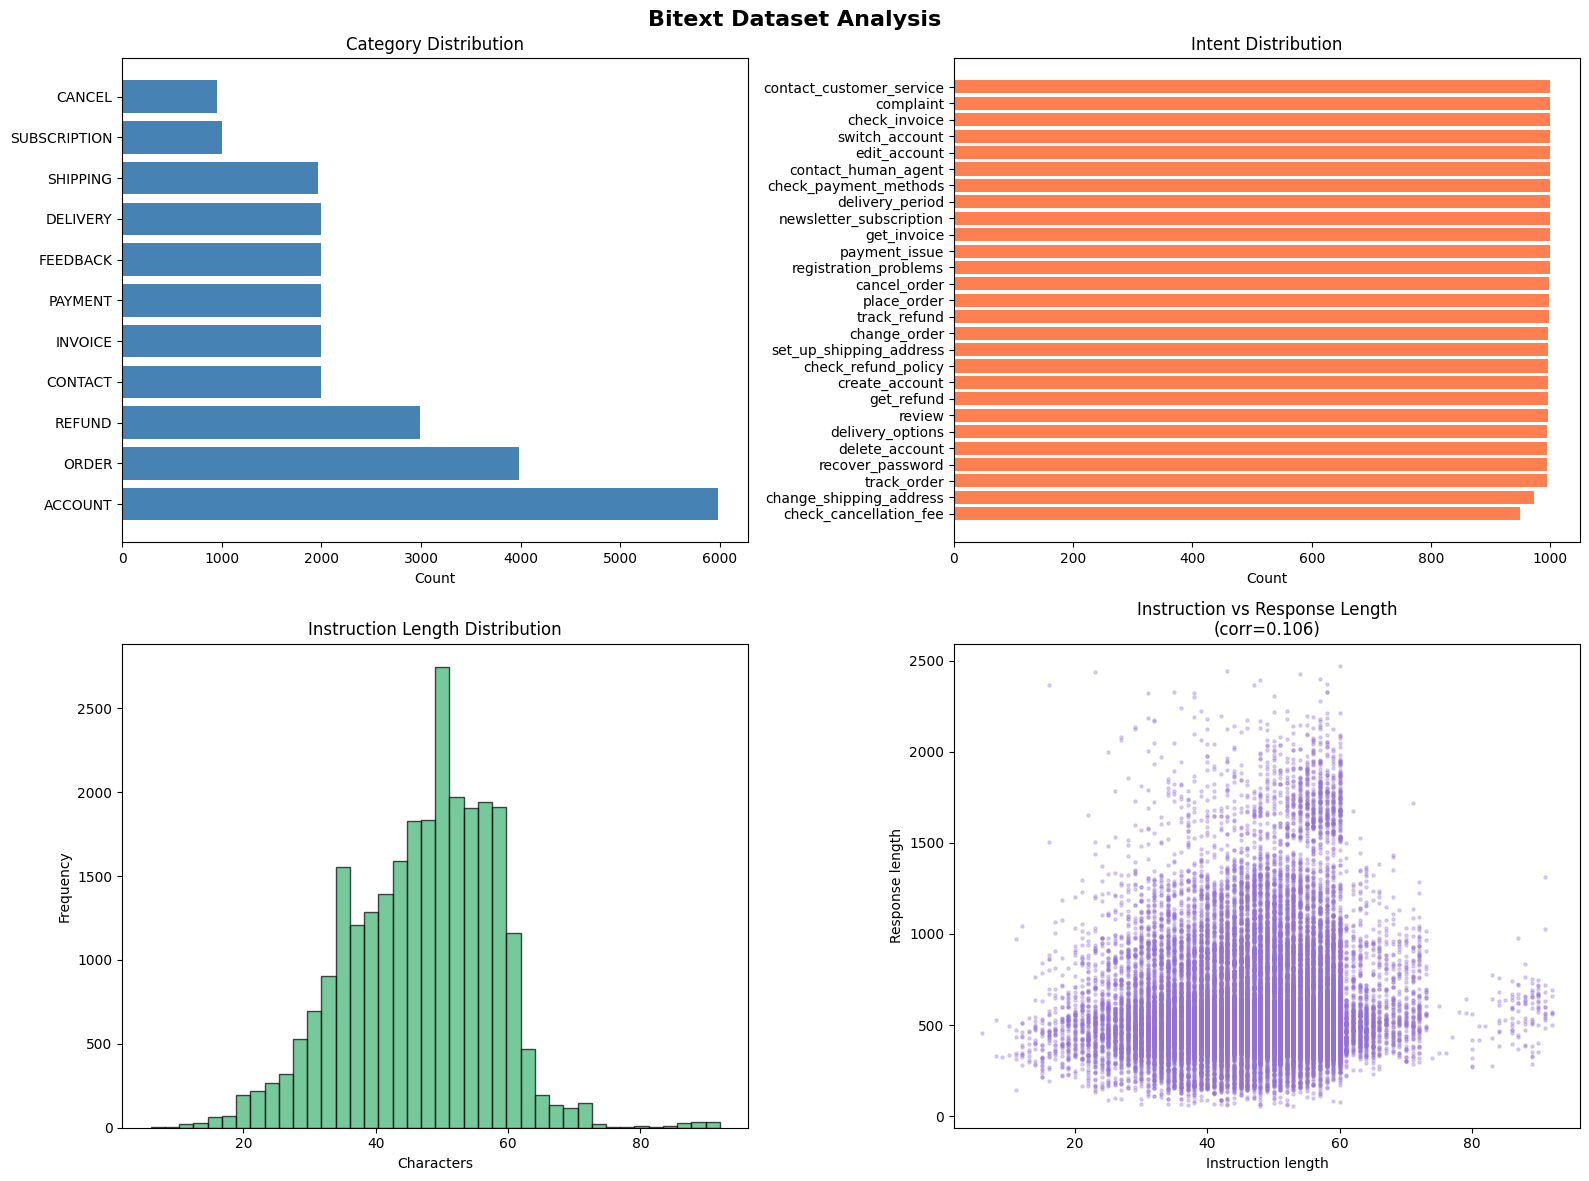


Plot saved: eda_bitext.png


In [6]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

print("="*60)
print("EDA — BITEXT CUSTOMER SUPPORT DATASET")
print("="*60)

bitext = load_dataset(
    "bitext/Bitext-customer-support-llm-chatbot-training-dataset",
    split="train"
)
df = bitext.to_pandas()

print(f"\nTotal examples : {len(df)}")
print(f"Columns        : {df.columns.tolist()}")

print(f"\nCategories ({df['category'].nunique()}):")
cat_dist = df["category"].value_counts()
for cat, count in cat_dist.items():
    bar = "█" * (count // 100)
    print(f"  {cat:30s}: {count:5d} {bar}")

print(f"\nIntents ({df['intent'].nunique()}):")
intent_dist = df["intent"].value_counts()
for intent, count in intent_dist.items():
    print(f"  {intent:35s}: {count:5d}")

df["instruction_len"] = df["instruction"].str.len()
df["response_len"]    = df["response"].str.len()

print(f"\nInstruction length (chars):")
print(f"  Mean   : {df['instruction_len'].mean():.0f}")
print(f"  Median : {df['instruction_len'].median():.0f}")
print(f"  Max    : {df['instruction_len'].max()}")

print(f"\nResponse length (chars):")
print(f"  Mean   : {df['response_len'].mean():.0f}")
print(f"  Median : {df['response_len'].median():.0f}")
print(f"  Max    : {df['response_len'].max()}")

corr = df[["instruction_len", "response_len"]].corr()
print(f"\nCorrelation (instruction ↔ response length):")
print(corr.round(3))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Bitext Dataset Analysis", fontsize=16, fontweight="bold")

# 1. Category distribution
axes[0,0].barh(cat_dist.index, cat_dist.values, color="steelblue")
axes[0,0].set_title("Category Distribution")
axes[0,0].set_xlabel("Count")

# 2. Intent distribution
axes[0,1].barh(intent_dist.index, intent_dist.values, color="coral")
axes[0,1].set_title("Intent Distribution")
axes[0,1].set_xlabel("Count")
axes[0,1].invert_yaxis()

# 3. Instruction length distribution
axes[1,0].hist(df["instruction_len"], bins=40, color="mediumseagreen",
               edgecolor="black", alpha=0.7)
axes[1,0].set_title("Instruction Length Distribution")
axes[1,0].set_xlabel("Characters")
axes[1,0].set_ylabel("Frequency")

# 4. Correlation heatmap instruction vs response
axes[1,1].scatter(df["instruction_len"], df["response_len"],
                  alpha=0.3, color="mediumpurple", s=5)
axes[1,1].set_title(f"Instruction vs Response Length\n(corr={corr.iloc[0,1]:.3f})")
axes[1,1].set_xlabel("Instruction length")
axes[1,1].set_ylabel("Response length")

plt.tight_layout()
plt.savefig('/kaggle/working/eda_bitext.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: eda_bitext.png")


In [ ]:
import json
import random
import os
from datasets import load_dataset
from datetime import datetime

print("="*60)
print("COMBINING DATASETS")
print("="*60)

# ── Auto-detect dataset path ───────────────────────────────
print("\nScanning /kaggle/input/...")
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.json'):
            print(f"  {os.path.join(root, f)}")

# Find the ecommerce dataset file
ECOMMERCE_PATH = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if 'ecommerce' in f.lower() and f.endswith('.json'):
            ECOMMERCE_PATH = os.path.join(root, f)
            break
    if ECOMMERCE_PATH:
        break

if not ECOMMERCE_PATH:
    raise FileNotFoundError(
        "Ecommerce dataset not found in /kaggle/input/. "
        "Add the dataset to this notebook via: Notebook settings → Add data"
    )

print(f"\nFound: {ECOMMERCE_PATH}")

# ── System prompts ─────────────────────────────────────────
ECOMMERCE_SYSTEM = (
    "You are an AI shopping assistant for an online clothing store. "
    "You can help customers: browse products, check availability, place orders, "
    "confirm payment, add delivery details, track orders, cancel orders, "
    "update orders, and process returns. "
    "Always call check_product_availability before creating any order. "
    "If the customer does not specify color or size, ask for them before proceeding. "
    "Keep responses short and clear."
)

BITEXT_SYSTEM = (
    "You are a helpful customer support assistant for an online clothing store. "
    "Help customers with their questions and issues politely and professionally."
)

# ── 1. Load ecommerce dataset ──────────────────────────────
print("\n[1/4] Loading ecommerce dataset...")
with open(ECOMMERCE_PATH, 'r', encoding='utf-8') as f:
    ecommerce_raw = json.load(f)

ecommerce_conversations = ecommerce_raw["conversations"]
print(f"  Ecommerce examples: {len(ecommerce_conversations)}")

# ── 2. Convert ecommerce to unified format ─────────────────
print("\n[2/4] Converting ecommerce to unified format...")

def convert_ecommerce(conversation):
    messages = []
    for msg in conversation["messages"]:
        role = msg["role"]
        if role == "assistant" and "tool_calls" in msg:
            tool    = msg["tool_calls"][0]
            content = f"<tool_call>{json.dumps(tool, ensure_ascii=False)}</tool_call>"
            messages.append({"role": "assistant", "content": content})
        elif role == "tool":
            # Raw JSON as user message — matches inference format
            messages.append({
                "role":    "user",
                "content": json.dumps(msg["content"], ensure_ascii=False),
            })
        elif role == "system":
            messages.append({"role": "system", "content": ECOMMERCE_SYSTEM})
        else:
            messages.append(msg)
    return {"messages": messages, "source": "ecommerce"}

ecommerce_formatted = [convert_ecommerce(c) for c in ecommerce_conversations]
print(f"  Converted: {len(ecommerce_formatted)} examples")

# Verify format of a sample
sample_msgs = ecommerce_formatted[0]["messages"]
for m in sample_msgs:
    role    = m["role"]
    preview = m["content"][:80].replace("\n", " ")
    print(f"  [{role:9s}] {preview}")

# ── 3. Load & convert bitext dataset ──────────────────────
print("\n[3/4] Loading bitext dataset...")
bitext = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset", split="train")
print(f"  Bitext examples: {len(bitext)}")

def convert_bitext(example):
    return {
        "messages": [
            {"role": "system",    "content": BITEXT_SYSTEM},
            {"role": "user",      "content": example["instruction"]},
            {"role": "assistant", "content": example["response"]},
        ],
        "source": "bitext"
    }

bitext_formatted = [convert_bitext(ex) for ex in bitext]
print(f"  Converted: {len(bitext_formatted)} examples")

# ── 4. Combine & shuffle ───────────────────────────────────
print("\n[4/4] Combining and shuffling...")
combined = ecommerce_formatted + bitext_formatted
random.seed(42)
random.shuffle(combined)

print(f"\n{'='*60}")
print(f"  Ecommerce : {len(ecommerce_formatted):>6,} ({len(ecommerce_formatted)/len(combined)*100:.1f}%)")
print(f"  Bitext    : {len(bitext_formatted):>6,} ({len(bitext_formatted)/len(combined)*100:.1f}%)")
print(f"  TOTAL     : {len(combined):>6,}")
print(f"{'='*60}")


In [8]:
import os

print("Splitting into train/validation...")

split_idx   = int(len(combined) * 0.9)
train_data  = combined[:split_idx]
val_data    = combined[split_idx:]

print(f"  Train : {len(train_data):,}")
print(f"  Val   : {len(val_data):,}")

save_path = '/kaggle/working/'

def save_jsonl(data, path):
    with open(path, 'w', encoding='utf-8') as f:
        for item in data:
            f.write(json.dumps(item, ensure_ascii=False) + '\n')
    print(f"  Saved: {path} ({len(data):,} examples)")

save_jsonl(train_data, f"{save_path}train.jsonl")
save_jsonl(val_data,   f"{save_path}val.jsonl")

stats = {
    "total":      len(combined),
    "train":      len(train_data),
    "val":        len(val_data),
    "ecommerce":  len(ecommerce_formatted),
    "bitext":     len(bitext_formatted),
    "created":    str(datetime.now())
}
with open(f"{save_path}dataset_stats.json", 'w') as f:
    json.dump(stats, f, indent=2)

print("\nDone! Dataset ready for training.")
print(f"Files saved to: {save_path}")


Splitting into train/validation...
  Train : 34,984
  Val   : 3,888
  Saved: /kaggle/working/train.jsonl (34,984 examples)
  Saved: /kaggle/working/val.jsonl (3,888 examples)

Done! Dataset ready for training.
Files saved to: /kaggle/working/


In [ ]:
from datasets import Dataset
import json

print("="*60)
print("PREPARING DATASET FOR TRAINING")
print("="*60)

MAX_TOKENS = 512

def load_jsonl(path):
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line.strip()))
    return data

train_raw = load_jsonl('/kaggle/working/train.jsonl')
val_raw   = load_jsonl('/kaggle/working/val.jsonl')
print(f"Train raw : {len(train_raw):,}")
print(f"Val raw   : {len(val_raw):,}")

def format_and_filter(raw_list):
    out, skipped = [], 0
    for example in raw_list:
        messages = []
        for msg in example['messages']:
            role    = msg['role']
            content = msg.get('content', '')
            if role == 'tool':
                role = 'user'
            if content:
                messages.append({'role': role, 'content': content})

        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False
        )
        n_tokens = len(tokenizer(text, add_special_tokens=False)["input_ids"])
        if n_tokens <= MAX_TOKENS:
            out.append({"text": text})
        else:
            skipped += 1
    return out, skipped

print(f"\nFormatting + filtering (max {MAX_TOKENS} tokens)...")
train_list, train_skip = format_and_filter(train_raw)
val_list,   val_skip   = format_and_filter(val_raw)

train_dataset = Dataset.from_list(train_list)
val_dataset   = Dataset.from_list(val_list)

print(f"\nTrain : {len(train_dataset):,}  (відфільтровано {train_skip:,})")
print(f"Val   : {len(val_dataset):,}  (відфільтровано {val_skip:,})")

sample = train_dataset[0]['text']
print(f"\nSample (перші 400 символів):")
print("-"*60)
print(sample[:400])
print("-"*60)

lengths = [
    len(tokenizer(d['text'], add_special_tokens=False)["input_ids"])
    for d in train_dataset
]
print(f"\nToken length stats (after filter):")
print(f"  Min    : {min(lengths)}")
print(f"  Max    : {max(lengths)}")
print(f"  Mean   : {int(sum(lengths)/len(lengths))}")
print(f"  All ≤ {MAX_TOKENS}: {all(l <= MAX_TOKENS for l in lengths)} ✓")

In [ ]:
import os
import torch
from trl import SFTTrainer, SFTConfig
from unsloth import is_bfloat16_supported

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
torch.cuda.empty_cache()

HF_REPO = "manoilokate/llama-3.2-1b-ecommerce-v1"

trainer = SFTTrainer(
    model              = model,
    tokenizer          = tokenizer,
    train_dataset      = train_dataset,
    eval_dataset       = val_dataset,
    args = SFTConfig(
        dataset_text_field           = "text",
        max_seq_length               = 512,
        dataset_num_proc             = 2,
        packing                      = False,
        per_device_train_batch_size  = 1,
        gradient_accumulation_steps  = 8,
        num_train_epochs             = 3,
        learning_rate                = 2e-4,
        fp16                         = not is_bfloat16_supported(),
        bf16                         = is_bfloat16_supported(),
        warmup_steps                 = 100,
        lr_scheduler_type            = "cosine",
        optim                        = "adamw_8bit",
        weight_decay                 = 0.01,
        seed                         = 42,
        logging_steps                = 50,
        eval_strategy                = "steps",
        eval_steps                   = 300,
        save_strategy                = "steps",
        save_steps                   = 300,
        save_total_limit             = 2,
        load_best_model_at_end       = True,
        metric_for_best_model        = "eval_loss",
        greater_is_better            = False,
        output_dir                   = '/kaggle/working/checkpoints',
        report_to                    = "none",
        push_to_hub                  = True,
    ),
)

print(f"Batch per device : 1  |  Grad accum : 8  |  Effective batch : 8")
print(f"Train examples   : {len(train_dataset):,}")
print(f"Eval/Save        : every 300 steps  (push to HF)")
print(f"\nStarting training...")

torch.cuda.empty_cache()
trainer_stats = trainer.train()

print(f"\n{'='*60}")
print(f"Training completed!")
print(f"  Runtime : {trainer_stats.metrics['train_runtime']/3600:.2f} h")
print(f"  Loss    : {trainer_stats.metrics['train_loss']:.4f}")
print(f"{'='*60}")

In [ ]:
# ── Final push to HuggingFace Hub ──────────────────────────
HF_REPO = "manoilokate/llama-3.2-1b-ecommerce-v1"

print(f"Pushing final LoRA adapter → {HF_REPO}")

model.push_to_hub_merged(
    HF_REPO,
    tokenizer,
    save_method = "lora",
    token       = HF_TOKEN_WRITE,
)

print(f"\nDone! https://huggingface.co/{HF_REPO}")
print(f'\nUpdate diploma-demo.ipynb: "Llama 3.2 1B": "{HF_REPO}"')